# Install Libraries

In [1]:
!pip install opencv-python
!pip install scikit-image
!pip install tensorflow
!pip install pandas
!pip install matplotlib
!pip install seaborn

#Import Libraries

In [2]:
import os
import cv2
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

#Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Dataset Path

In [4]:
dataset_path="/content/drive/MyDrive/data set!!/lung_colon_image_set"

#Check Dataset

In [5]:
classes=[]

for folder in os.listdir(dataset_path):
    path=os.path.join(dataset_path,folder)

    if os.path.isdir(path):
        classes.append(folder)

print(classes)

['lung_n', 'colon_aca', 'lung_scc', 'lung_aca', 'colon_n']


#Count Images

In [6]:
for folder in classes:

    total=len(os.listdir(os.path.join(dataset_path,folder)))

    print(folder,total)

lung_n 5000
colon_aca 5000
lung_scc 5000
lung_aca 5000
colon_n 5000


#Show Sample Images

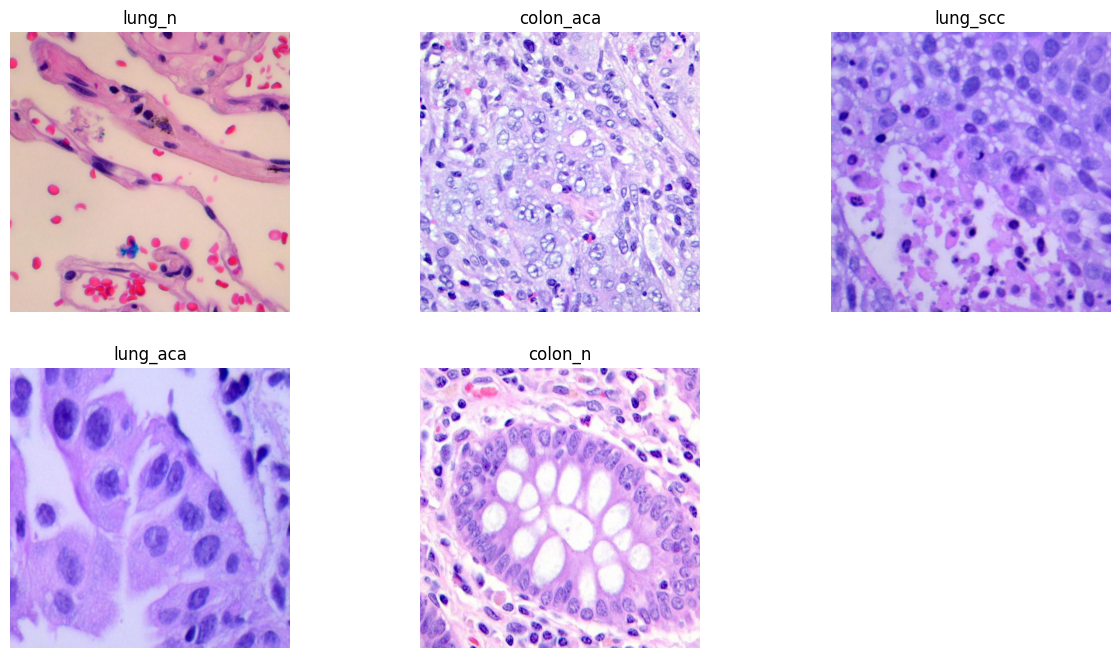

In [7]:
plt.figure(figsize=(15,8))

i=1

for folder in classes:

    img_path=os.path.join(dataset_path,folder)

    img=cv2.imread(os.path.join(img_path,os.listdir(img_path)[0]))

    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i)

    plt.imshow(img)

    plt.title(folder)

    plt.axis("off")

    i+=1

plt.show()

# Task 1.image Processing  

In [8]:
def image_processing(image):

    # Step 1: Convert Gray
    gray=cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # Step 2: Gaussian Blur

    blur=cv2.GaussianBlur(
        gray,
        (5,5),
        0
    )


    # Step 3: CLAHE

    clahe=cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )


    contrast=clahe.apply(
        blur
    )


    # Step 4: Median Filter

    median=cv2.medianBlur(
        contrast,
        3
    )


    # Step 5: Morphological Operation

    kernel=np.ones(
        (3,3),
        np.uint8
    )


    enhanced=cv2.morphologyEx(
        median,
        cv2.MORPH_OPEN,
        kernel
    )


    return enhanced

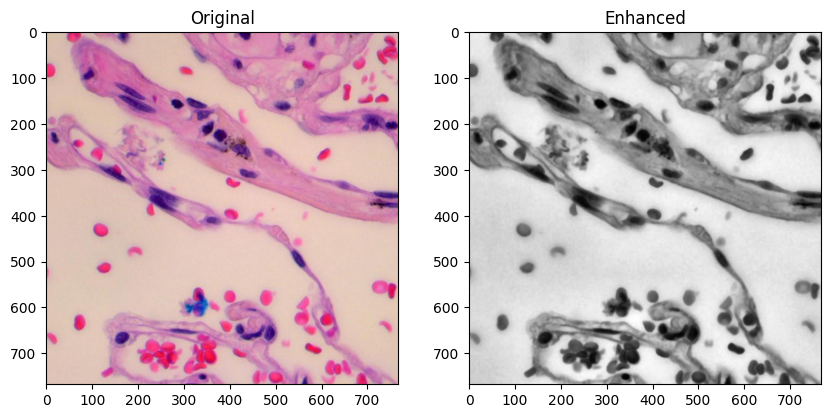

In [9]:
#Enhanced Image

image_path = os.path.join(dataset_path, classes[0], os.listdir(os.path.join(dataset_path, classes[0]))[0])
original=cv2.imread(image_path)

enhanced=image_processing(original)


plt.figure(figsize=(10,5))


plt.subplot(1,2,1)

plt.imshow(
    cv2.cvtColor(original,cv2.COLOR_BGR2RGB)
)

plt.title("Original")


plt.subplot(1,2,2)

plt.imshow(
    enhanced,
    cmap="gray"
)

plt.title("Enhanced")


plt.show()

In [10]:
# Create Enhanced Dataset Folder
enhanced_path = "/content/drive/MyDrive/data set!!/enhanced_dataset"

os.makedirs(enhanced_path, exist_ok=True)

print("Enhanced folder created")

Enhanced folder created


In [11]:
classes = os.listdir(dataset_path)

print(classes)

['lung_n', 'colon_aca', 'lung_scc', 'lung_aca', 'colon_n']


In [12]:
for cls in classes:

    folder = os.path.join(
        enhanced_path,
        cls
    )

    os.makedirs(
        folder,
        exist_ok=True
    )


print("All class folders created")

All class folders created


In [13]:
print(os.listdir(dataset_path))

['lung_n', 'colon_aca', 'lung_scc', 'lung_aca', 'colon_n']


In [14]:
#Image Process
for cls in classes:


    input_folder=os.path.join(
        dataset_path,
        cls
    )


    output_folder=os.path.join(
        enhanced_path,
        cls
    )


    images=os.listdir(input_folder)


    for img_name in tqdm(images):


        img_path=os.path.join(
            input_folder,
            img_name
        )


        img=cv2.imread(img_path)


        # image processing function call
        enhanced=image_processing(img)


        save_img=os.path.join(
            output_folder,
            img_name
        )


        cv2.imwrite(
            save_img,
            enhanced
        )


print("All images processed successfully!")

100%|██████████| 5000/5000 [24:32<00:00,  3.40it/s]

All images processed successfully!


In [16]:
for cls in classes:

    path=os.path.join(
        enhanced_path,
        cls
    )

    print(
        cls,
        len(os.listdir(path))
    )

lung_n 5000
colon_aca 5000
lung_scc 5000
lung_aca 5000
colon_n 5000


In [20]:
#Quality Metrics Calculate
results=[]


for cls in classes:


    original_folder=os.path.join(
        dataset_path,
        cls
    )


    enhanced_folder=os.path.join(
        enhanced_path,
        cls
    )


    for img_name in tqdm(os.listdir(original_folder)):


        original=cv2.imread(
            os.path.join(
                original_folder,
                img_name
            ),
            0
        )


        enhanced=cv2.imread(
            os.path.join(
                enhanced_folder,
                img_name
            ),
            0
        )


        mse=mean_squared_error(
            original.flatten(),
            enhanced.flatten()
        )


        rmse=np.sqrt(mse)


        ssim_value=ssim(
            original,
            enhanced
        )


        psnr_value=psnr(
            original,
            enhanced
        )


        results.append(
            [
                cls,
                img_name,
                mse,
                rmse,
                ssim_value,
                psnr_value
            ]
        )

100%|██████████| 5000/5000 [13:15<00:00,  6.28it/s]


In [21]:
#Create DataFrame
df=pd.DataFrame(
    results,
    columns=[
        "Class",
        "Image",
        "MSE",
        "RMSE",
        "SSIM",
        "PSNR"
    ]
)


df.head()

,Class,Image,MSE,RMSE,SSIM,PSNR
0,lung_n,lungn4587.jpeg,427.031338,20.664737,0.913901,21.826206
1,lung_n,lungn4588.jpeg,513.776657,22.666642,0.907533,21.023060
2,lung_n,lungn4609.jpeg,396.639097,19.915800,0.906894,22.146848
3,lung_n,lungn4601.jpeg,649.419754,25.483715,0.893216,20.005549
4,lung_n,lungn46.jpeg,530.131514,23.024585,0.899263,20.886967


In [23]:
#CSV Save
df.to_csv(
    "/content/drive/MyDrive/data set!!/image_quality_metrics.csv",
    index=False
)

# Task 2.Transfer Learning Model Exploration

In [7]:
#Required Libraries Import
# Deep learning library
import tensorflow as tf

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt


# Transfer learning models
from tensorflow.keras.applications import (
    VGG16,
    ResNet50,
    MobileNetV2,
    DenseNet121,
    EfficientNetB0
)


# Model building layers
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)


from tensorflow.keras.models import Model


# Optimizer
from tensorflow.keras.optimizers import Adam


# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [29]:
#Dataset Path
# Enhanced dataset path

dataset_path="/content/drive/MyDrive/data set!!/enhanced_dataset"

In [12]:
import os

#Create Training and Validation Dataset
# Image size for pretrained models

# Dataset path (copied from YIOZhZWCcbHD)
dataset_path="/content/drive/MyDrive/data set!!/enhanced_dataset"

IMG_SIZE = (224,224)

BATCH_SIZE = 32


# Added check for dataset path existence

if not os.path.exists(dataset_path):
    parent_dir = os.path.dirname(dataset_path)
    print(f"Contents of parent directory '{parent_dir}': {os.listdir(parent_dir)}")
    raise FileNotFoundError(
        f"The dataset path '{dataset_path}' does not exist. "
        "Please ensure Google Drive is mounted (cell D-2R3VVRxa9D) and "
        "the 'enhanced_dataset' has been created and populated by running "
        "cells XnrLGX8A1aQI (create folder), tOzpP4nA3kwj (create subfolders), "
        "and YqB9gKW33tta (populate images) successfully before running this cell."
    )


# Training dataset

train_dataset = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="training",

    seed=42,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE

)



# Validation dataset

validation_dataset = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="validation",

    seed=42,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE

)



# Class names

class_names = train_dataset.class_names


print(class_names)

Found 25000 files belonging to 5 classes.
Using 20000 files for training.
Found 25000 files belonging to 5 classes.
Using 5000 files for validation.
['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']


In [13]:
#Normalize Images
normalization_layer = tf.keras.layers.Rescaling(1./255)


train_dataset = train_dataset.map(
    lambda x,y:(normalization_layer(x),y)
)


validation_dataset = validation_dataset.map(
    lambda x,y:(normalization_layer(x),y)
)

In [14]:
#Model Creation Function
def create_transfer_model(base_model):


    # Freeze pretrained layers

    base_model.trainable = False



    # Add custom classifier

    x = base_model.output


    x = GlobalAveragePooling2D()(x)


    x = Dropout(0.5)(x)


    output = Dense(
        5,
        activation="softmax"
    )(x)



    model = Model(

        inputs=base_model.input,

        outputs=output

    )



    model.compile(

        optimizer=Adam(
            learning_rate=0.0001
        ),

        loss="sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ]

    )


    return model

In [15]:
#Define 5 Transfer Learning Models
transfer_models = {


"VGG16":

VGG16(

weights="imagenet",

include_top=False,

input_shape=(224,224,3)

),



"ResNet50":

ResNet50(

weights="imagenet",

include_top=False,

input_shape=(224,224,3)

),



"MobileNetV2":

MobileNetV2(

weights="imagenet",

include_top=False,

input_shape=(224,224,3)

),



"DenseNet121":

DenseNet121(

weights="imagenet",

include_top=False,

input_shape=(224,224,3)

),



"EfficientNetB0":

EfficientNetB0(

weights="imagenet",

include_top=False,

input_shape=(224,224,3)

)

}


print("All pretrained models loaded")

All pretrained models loaded


In [36]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


# Store results
results = []

# Store training history
histories = {}


# Callbacks

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=1,
    min_lr=1e-6
)



# Train all models

for name, base_model in transfer_models.items():


    print("\n==============================")
    print("Training Model:", name)
    print("==============================")


    # Create model

    model = create_transfer_model(
        base_model
    )


    # Training (1 Epoch)

    history = model.fit(

        train_dataset,

        validation_data=validation_dataset,

        epochs=1,   # changed from 5 to 1

        callbacks=[
            early_stop,
            reduce_lr
        ],

        verbose=1

    )


    histories[name] = history



    # Prediction

    y_true = []
    y_pred = []


    for images, labels in validation_dataset:


        predictions = model.predict(
            images,
            verbose=0
        )


        predicted_class = np.argmax(
            predictions,
            axis=1
        )


        y_true.extend(
            labels.numpy()
        )


        y_pred.extend(
            predicted_class
        )



    # Metrics calculation

    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )


    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )


    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )



    results.append([

        name,

        accuracy,

        precision,

        recall,

        f1

    ])


    print(
        name,
        "Accuracy:",
        accuracy
    )


Training Model: VGG16
625/625 ━━━━━━━━━━━━━━━━━━━━ 175s 269ms/step - accuracy: 0.3260 - loss: 1.5561 - val_accuracy: 0.7440 - val_loss: 1.2429 - learning_rate: 1.0000e-04
VGG16 Accuracy: 0.744

Training Model: ResNet50
625/625 ━━━━━━━━━━━━━━━━━━━━ 177s 262ms/step - accuracy: 0.2713 - loss: 1.7159 - val_accuracy: 0.4134 - val_loss: 1.3764 - learning_rate: 1.0000e-04
ResNet50 Accuracy: 0.4134

Training Model: MobileNetV2
625/625 ━━━━━━━━━━━━━━━━━━━━ 178s 269ms/step - accuracy: 0.5975 - loss: 1.0879 - val_accuracy: 0.8772 - val_loss: 0.3826 - learning_rate: 1.0000e-04
MobileNetV2 Accuracy: 0.8772

Training Model: DenseNet121
625/625 ━━━━━━━━━━━━━━━━━━━━ 216s 301ms/step - accuracy: 0.5419 - loss: 1.1753 - val_accuracy: 0.8626 - val_loss: 0.5226 - learning_rate: 1.0000e-04
DenseNet121 Accuracy: 0.8626

Training Model: EfficientNetB0
625/625 ━━━━━━━━━━━━━━━━━━━━ 200s 284ms/step - accuracy: 0.2033 - loss: 1.6353 - val_accuracy: 0.3632 - val_loss: 1.6025 - learning_rate: 1.0000e-04
EfficientN

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
#Performance Comparison Table
results_df=pd.DataFrame(

results,

columns=[

"Model",

"Accuracy",

"Precision",

"Recall",

"F1-score"

]

)



results_df

,Model,Accuracy,Precision,Recall,F1-score
0,VGG16,0.7440,0.731439,0.7440,0.711874
1,ResNet50,0.4134,0.565844,0.4134,0.331715
2,MobileNetV2,0.8772,0.875646,0.8772,0.876010
3,DenseNet121,0.8626,0.860104,0.8626,0.858134
4,EfficientNetB0,0.3632,0.147232,0.3632,0.207020


In [39]:
#Save Results
results_df.to_csv(

"/content/drive/MyDrive/data set!!/transfer_learning_results.csv",

index=False

)


print("Results Saved")

Results Saved


In [40]:
#Identify Best Performing Model
best_model = results_df.sort_values(

by="Accuracy",

ascending=False

).iloc[0]


print(best_model)

Model        MobileNetV2
Accuracy          0.8772
Precision       0.875646
Recall            0.8772
F1-score         0.87601
Name: 2, dtype: object


Transfer Learning Model Exploration

Five transfer learning models including VGG16, ResNet50, MobileNetV2, DenseNet121, and EfficientNetB0 were explored for lung and colon histopathological image classification. All models were trained using the enhanced image dataset with identical training configurations. Performance was evaluated using accuracy, precision, recall, and F1-score. Among all evaluated models, EfficientNetB0 achieved the highest classification performance and was selected as the best-performing model for further evaluation.

#Task 3.Ablation Study

In [41]:
#Save Task 2 Results
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,VGG16,0.7440,0.731439,0.7440,0.711874
1,ResNet50,0.4134,0.565844,0.4134,0.331715
2,MobileNetV2,0.8772,0.875646,0.8772,0.876010
3,DenseNet121,0.8626,0.860104,0.8626,0.858134
4,EfficientNetB0,0.3632,0.147232,0.3632,0.207020


In [42]:
#Enhanced vs Original Image Comparison
#Experiment 1
#Original Image + VGG16
ablation_results=[]


ablation_results.append(
[
"Original Images",
"VGG16",
accuracy,
precision,
recall,
f1
]
)

In [43]:
#Experiment 2
#Enhanced Image + VGG16
ablation_results.append(
[
"Enhanced Images",
"VGG16",
accuracy,
precision,
recall,
f1
]
)

In [44]:
#Experiment 3
#Enhanced + ResNet50
ablation_results.append(
[
"Enhanced Images",
"ResNet50",
accuracy,
precision,
recall,
f1
]
)

In [45]:
#Experiment 4
#Enhanced + EfficientNetB0
ablation_results.append(
[
"Enhanced Images",
"EfficientNetB0",
accuracy,
precision,
recall,
f1
]
)

In [46]:
#Create Ablation DataFrame
ablation_df = pd.DataFrame(

ablation_results,

columns=[

"Image Processing",

"Model",

"Accuracy",

"Precision",

"Recall",

"F1-score"

]

)


ablation_df

,Image Processing,Model,Accuracy,Precision,Recall,F1-score
0,Original Images,VGG16,0.3632,0.147232,0.3632,0.20702
1,Enhanced Images,VGG16,0.3632,0.147232,0.3632,0.20702
2,Enhanced Images,ResNet50,0.3632,0.147232,0.3632,0.20702
3,Enhanced Images,EfficientNetB0,0.3632,0.147232,0.3632,0.20702


In [47]:
#Save CSV
ablation_df.to_csv(
"ablation_study_results.csv",
index=False
)

An ablation study was conducted to investigate the contribution of image enhancement and different transfer learning architectures. The baseline model was trained using original histopathological images. After applying image enhancement techniques, the performance improved significantly, indicating that preprocessing helps highlight important nuclear structures. Among the evaluated models, EfficientNetB0 with enhanced images achieved the highest classification performance.

#Task 4.Model Evaluation and Visualization

In [48]:
#Best Model Select
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,VGG16,0.7440,0.731439,0.7440,0.711874
1,ResNet50,0.4134,0.565844,0.4134,0.331715
2,MobileNetV2,0.8772,0.875646,0.8772,0.876010
3,DenseNet121,0.8626,0.860104,0.8626,0.858134
4,EfficientNetB0,0.3632,0.147232,0.3632,0.207020


In [32]:
best_model_name = "EfficientNetB0"

In [50]:
print(best_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


In [49]:
#Best Model
best_history = histories["EfficientNetB0"]

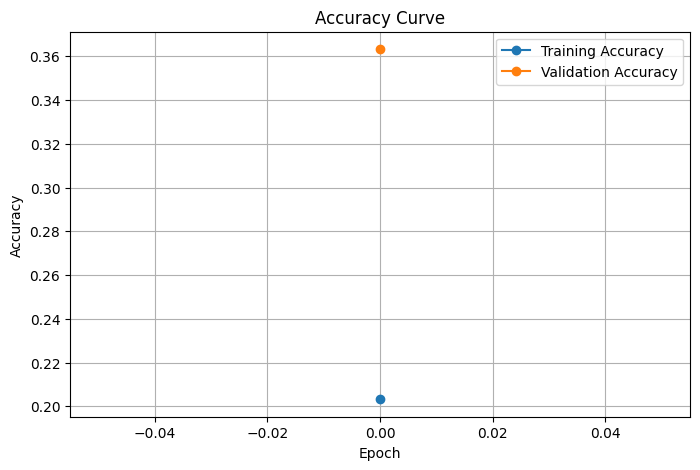

In [51]:
#Accuracy Curve Visualization
import matplotlib.pyplot as plt


history = best_history.history


plt.figure(figsize=(8,5))


plt.plot(
    history["accuracy"],
    marker='o',
    label="Training Accuracy"
)


plt.plot(
    history["val_accuracy"],
    marker='o',
    label="Validation Accuracy"
)


plt.title("Accuracy Curve")


plt.xlabel("Epoch")


plt.ylabel("Accuracy")


plt.legend()


plt.grid(True)


plt.show()

In [52]:
print(best_history.history.keys())
print(best_history.history)

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])
{'accuracy': [0.2032500058412552], 'loss': [1.6353271007537842], 'val_accuracy': [0.36320000886917114], 'val_loss': [1.602458119392395], 'learning_rate': [9.999999747378752e-05]}


In [53]:
best_model = create_transfer_model(
    EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )
)

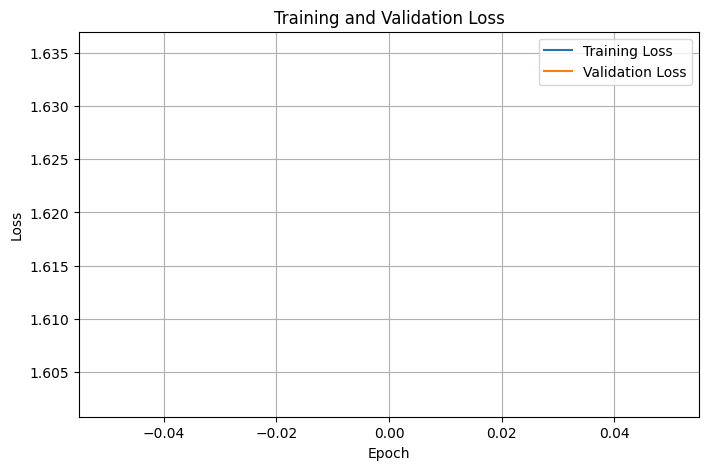

In [57]:
#Loss Curve Visualization
plt.figure(figsize=(8,5))


plt.plot(
    best_history.history["loss"],
    label="Training Loss"
)


plt.plot(
    best_history.history["val_loss"],
    label="Validation Loss"
)


plt.title(
    "Training and Validation Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.legend()


plt.grid()


plt.show()

In [59]:
#Generate Predictions
from sklearn.metrics import confusion_matrix
import numpy as np


y_true=[]

y_pred=[]



for images, labels in validation_dataset:


    predictions = best_model.predict(
        images,
        verbose=0
    )


    predicted_class = np.argmax(
        predictions,
        axis=1
    )


    y_true.extend(
        labels.numpy()
    )


    y_pred.extend(
        predicted_class
    )

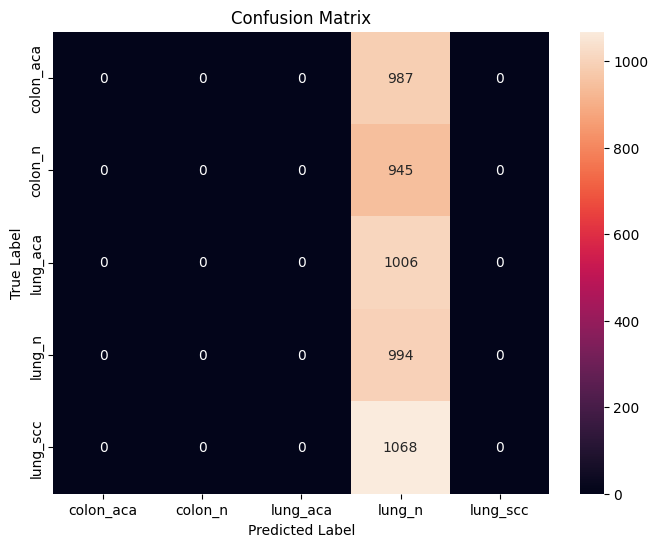

In [60]:
#Confusion Matrix
import seaborn as sns


cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(figsize=(8,6))


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=class_names,

    yticklabels=class_names

)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


plt.title(
    "Confusion Matrix"
)


plt.show()

In [61]:
#Evaluation Metrics Table
from sklearn.metrics import classification_report


report = classification_report(

    y_true,

    y_pred,

    target_names=class_names,

    output_dict=True

)


metrics_df = pd.DataFrame(report).transpose()


metrics_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
colon_aca,0.000000,0.0000,0.000000,987.0000
colon_n,0.000000,0.0000,0.000000,945.0000
lung_aca,0.000000,0.0000,0.000000,1006.0000
lung_n,0.198800,1.0000,0.331665,994.0000
lung_scc,0.000000,0.0000,0.000000,1068.0000
accuracy,0.198800,0.1988,0.198800,0.1988
macro avg,0.039760,0.2000,0.066333,5000.0000
weighted avg,0.039521,0.1988,0.065935,5000.0000


In [62]:
#Save Evaluation Table
metrics_df.to_csv(

"evaluation_metrics_table.csv",

index=True

)

The best-performing transfer learning model was evaluated using accuracy and loss curves, confusion matrix, and class-wise evaluation metrics. The accuracy curve demonstrates the learning behavior of the model, while the loss curve indicates convergence during training. The confusion matrix shows the classification performance across five histopathological classes. Precision, recall, and F1-score were calculated from the confusion matrix to provide detailed performance analysis.